# Exploratory Data Analysis (EDA) Report

## Movie Recommendation System – Phase 4 Project

---

# 1. Introduction

This report presents an Exploratory Data Analysis (EDA) of a movie dataset used for building a recommendation system. The goal is to understand data structure, patterns, distributions, and relationships between features such as ratings, genres, popularity, and languages.

---

# 2. Dataset Overview

The dataset contains movie-related information including:

* User ratings
* Movie metadata (title, genres, overview)
* Popularity metrics
* Vote averages
* Release year and language

### Key Columns Used:

* `rating` – User rating
* `vote_average` – Average movie rating
* `genres_x` – Movie genres
* `original_language` – Language of movie
* `popularity` – Popularity score
* `year` – Release year




In [3]:
#load libraries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# loading data set

In [4]:
final_dataset = pd.read_csv('final_dataset.csv')


In [21]:
final_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321026 entries, 0 to 321025
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   userid             321026 non-null  int64         
 1   movieid            321026 non-null  int64         
 2   rating             321026 non-null  float64       
 3   timestamp          321026 non-null  object        
 4   clean_title        321026 non-null  object        
 5   id                 321026 non-null  int64         
 6   vote_average       321026 non-null  float64       
 7   vote_count         321026 non-null  int64         
 8   release_date       262143 non-null  datetime64[ns]
 9   revenue            321026 non-null  int64         
 10  runtime            321026 non-null  int64         
 11  adult              321026 non-null  bool          
 12  budget             321026 non-null  int64         
 13  imdb_id            197481 non-null  object  

In [22]:
# Basic Information ======================
print("Dataset Shape:", final_dataset.shape)
print("\nNumerical Columns Summary:")
print(final_dataset.describe())

Dataset Shape: (321026, 25)

Numerical Columns Summary:
              userid        movieid         rating            id  \
count  321026.000000  321026.000000  321026.000000  3.210260e+05   
mean      327.241987   22761.279666       3.466149  6.911236e+05   
min         1.000000       1.000000       0.500000  2.000000e+00   
25%       177.000000    1022.000000       3.000000  7.016000e+04   
50%       326.000000    2881.000000       3.500000  6.488110e+05   
75%       479.000000   30894.000000       4.000000  1.225334e+06   
max       610.000000  193609.000000       5.000000  1.677097e+06   
std       183.544943   39511.020184       1.026394  5.625977e+05   

        vote_average     vote_count                   release_date  \
count  321026.000000  321026.000000                         262143   
mean        3.052475    1185.342770  1999-11-12 07:33:29.722937600   
min         0.000000       0.000000            1893-02-01 00:00:00   
25%         0.000000       0.000000            1990

## type conversion 
 numerical & date coonversion
 converts these columns from strings to floating-point numbers
 converts a string into a Datetime object 

In [7]:
final_dataset['vote_average'] = pd.to_numeric(final_dataset['vote_average'], errors='coerce')
final_dataset['popularity'] = pd.to_numeric(final_dataset['popularity'], errors='coerce')
final_dataset['release_date'] = pd.to_datetime(final_dataset['release_date'], errors='coerce')
print("vote_average column data type:", final_dataset['vote_average'].dtype)
print("popularity column data type:", final_dataset['popularity'].dtype)
print("release_date column data type:", final_dataset['release_date'].dtype)

vote_average column data type: float64
popularity column data type: float64
release_date column data type: datetime64[ns]


# DATA ANALISIS

## Popularity vs Rating 
### Weak Relationship
* The correlation value you printed is likely close to 0 .
* This indicates a weak positive relationship between popularity and rating.
   As popularity increases, ratings do not consistently increase

In [8]:
correlation = final_dataset['popularity'].corr(final_dataset['vote_average'])
correlation

np.float64(0.5467846182700887)

Text(0, 0.5, 'Vote Average')

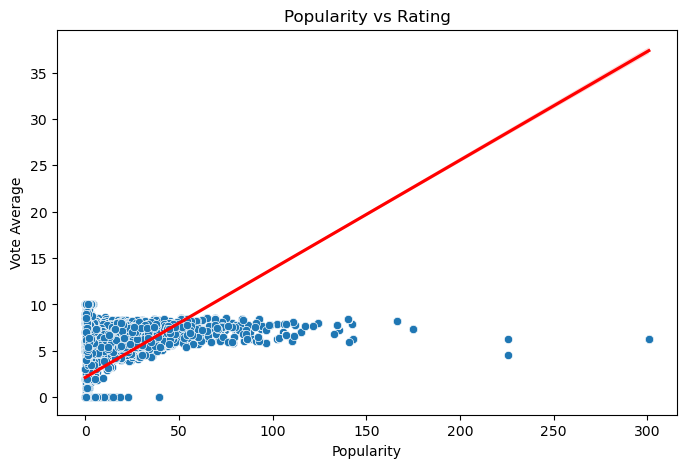

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x='popularity',y='vote_average',data=final_dataset)

# Optional: add trend line
sns.regplot(x='popularity',y='vote_average',data=final_dataset,scatter=False,color='red')

plt.title("Popularity vs Rating")
plt.xlabel("Popularity")
plt.ylabel("Vote Average")

## avarage rating by genre
Insight:
* action and adventure tend to have higher average ratings
* Some popular genres have moderate ratings due to volume

In [10]:
final_genre = final_dataset[['genres', 'vote_average']].copy()
final_genre['genres'] = final_genre['genres'].str.split(',')
final_genre = final_genre.explode('genres')

avg_rating = final_genre.groupby('genres')['vote_average'].mean()
avg_rating

genres
 Action            5.666947
 Adventure         5.930138
 Animation         5.290313
 Comedy            5.139934
 Crime             5.774519
                     ...   
Science Fiction    4.855806
TV Movie           3.624236
Thriller           3.890241
War                4.287347
Western            4.212595
Name: vote_average, Length: 473, dtype: float64

# VISUALIZATION

# Movie ratings distribution


* Most movies fall in mid-to-high rating range
* Few extremely low-rated movies exist


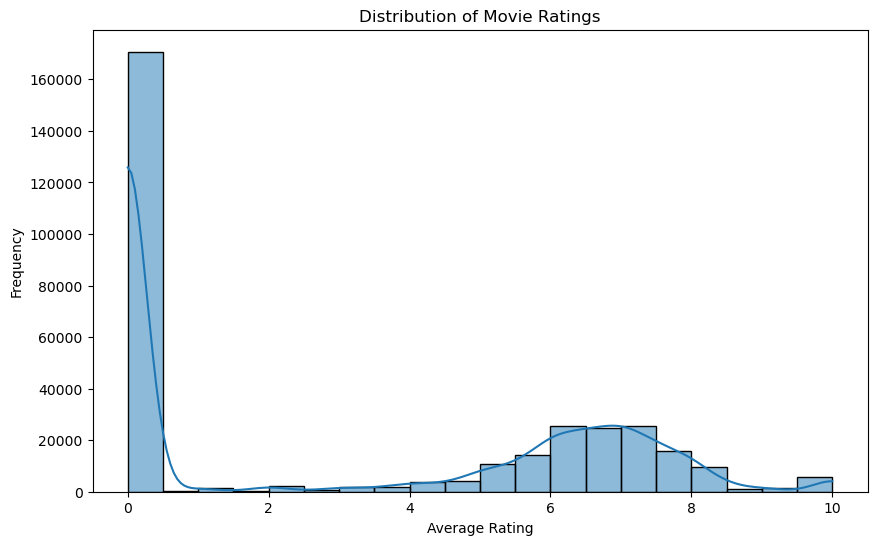

In [11]:
# movie rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(final_dataset['vote_average'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")          
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

# genre distribution
This code creates a frequency visualization of the most common genres in the dataset. 

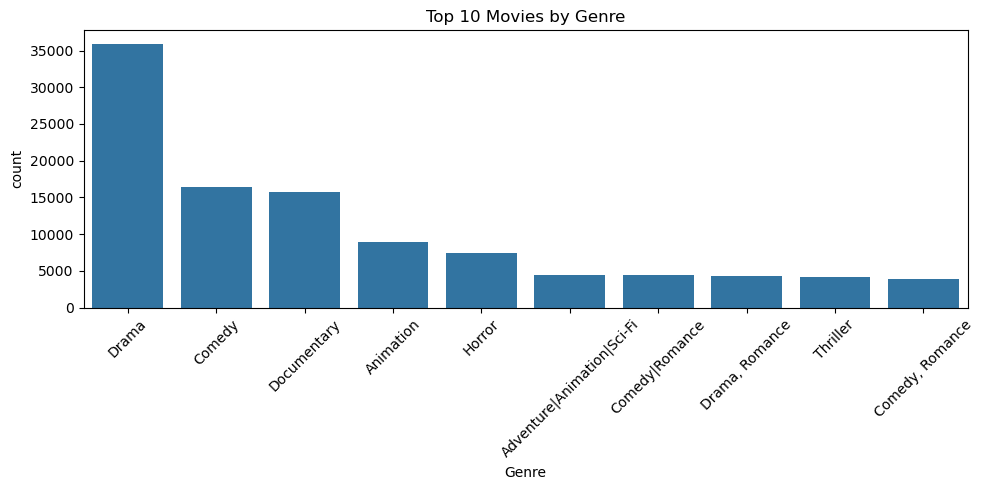

In [12]:

# Top 10 Genres
top_genres = final_dataset['genres'].value_counts().nlargest(10).index
plt.figure(figsize=(10, 5))
sns.countplot(x='genres', data=final_dataset[final_dataset['genres'].isin(top_genres)], order=top_genres)
plt.title("Top 10 Movies by Genre")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Genre vs Rating

* Helps identify quality vs quantity trends


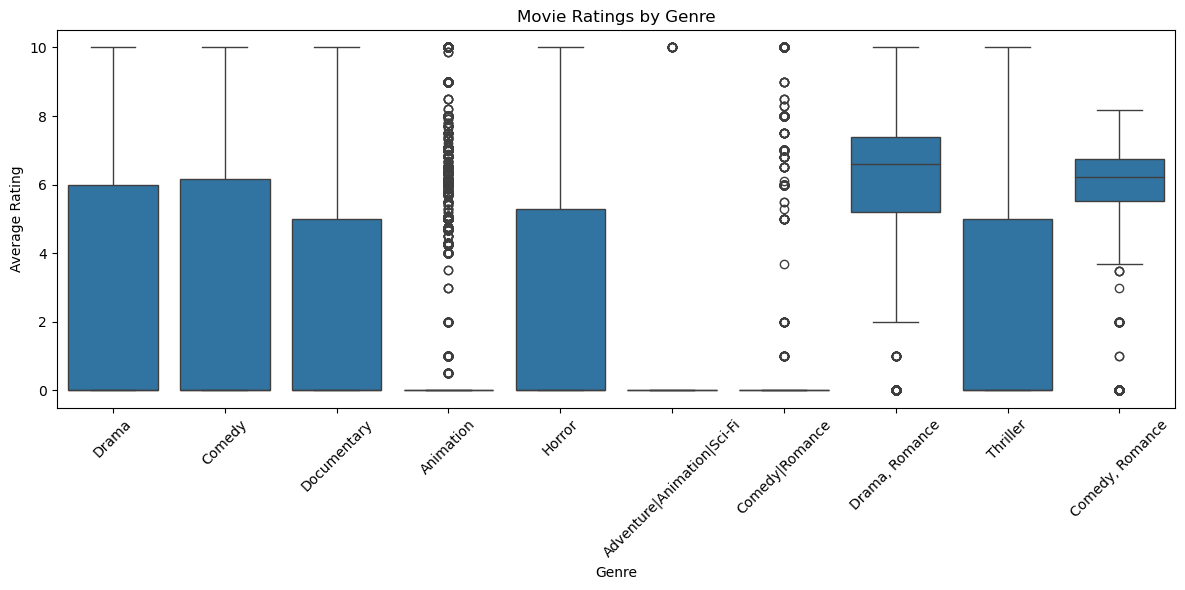

In [13]:
# genre vs rating
plt.figure(figsize=(12, 6))
sns.boxplot(x='genres', y='vote_average', data=final_dataset[final_dataset['genres'].isin(top_genres)], order=top_genres)
plt.title("Movie Ratings by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue & budget
This code creates a Scatter Plot to visualize the relationship between how much a movie cost to make (Budget) and how much it earned (Revenue)

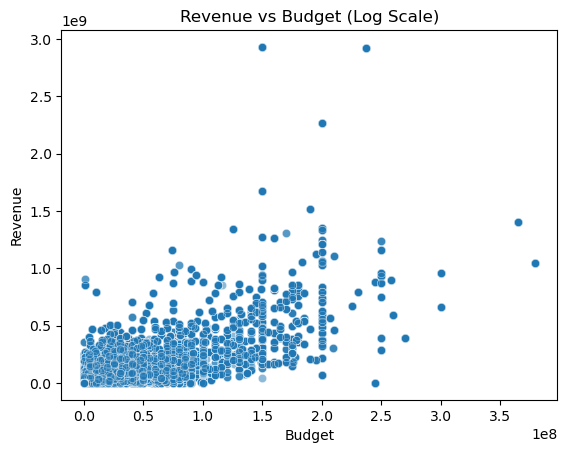

In [14]:
sns.scatterplot(x='budget', y='revenue', data=final_dataset, alpha=0.5)
plt.title("Revenue vs Budget (Log Scale)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

# Distribution of Languages
* English is dominant language


this code creates a frequency distribution bar chart for the most common languages in the dataset.


## language_map = {
    'en': 'English',
    'fr': 'French',
    'es': 'Spanish',
    'de': 'German',
    'it': 'Italian',
    'ja': 'Japanese',
    'ko': 'Korean',
    'zh': 'Chinese',
    'hi': 'Hindi',
    'ru': 'Russian',
    'pt': 'Portuguese',
    'ar': 'Arabic'
}

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'en'),
  Text(1, 0, 'fr'),
  Text(2, 0, 'zh'),
  Text(3, 0, 'ru'),
  Text(4, 0, 'es'),
  Text(5, 0, 'ja'),
  Text(6, 0, 'de'),
  Text(7, 0, 'pt')])

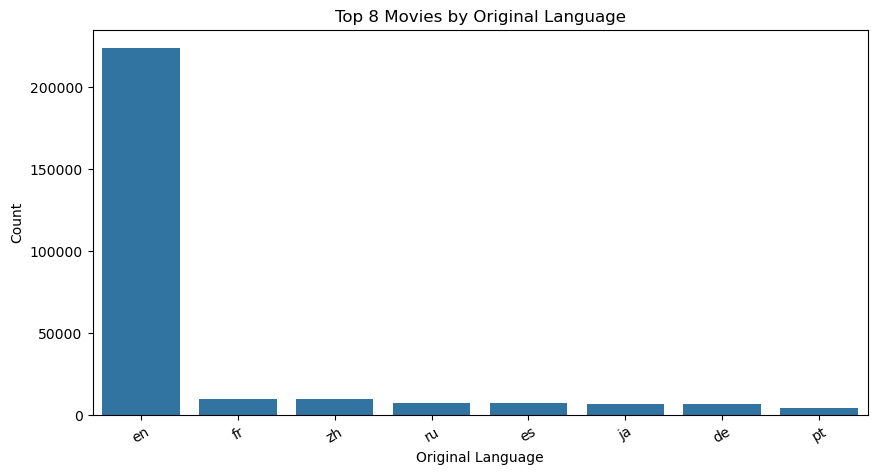

In [15]:
# Get top 8 languages
top_langs = final_dataset['original_language'].value_counts().head(8).index

plt.figure(figsize=(10, 5))  # adjust size for better fit

sns.countplot(x='original_language', data=final_dataset[final_dataset['original_language'].isin(top_langs)], order=top_langs)

plt.title("Top 8 Movies by Original Language")
plt.xlabel("Original Language")
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=30)

## numerical feature
This code block creates a 2x2 grid of histograms to analyze the distributions of your most important numerical variables

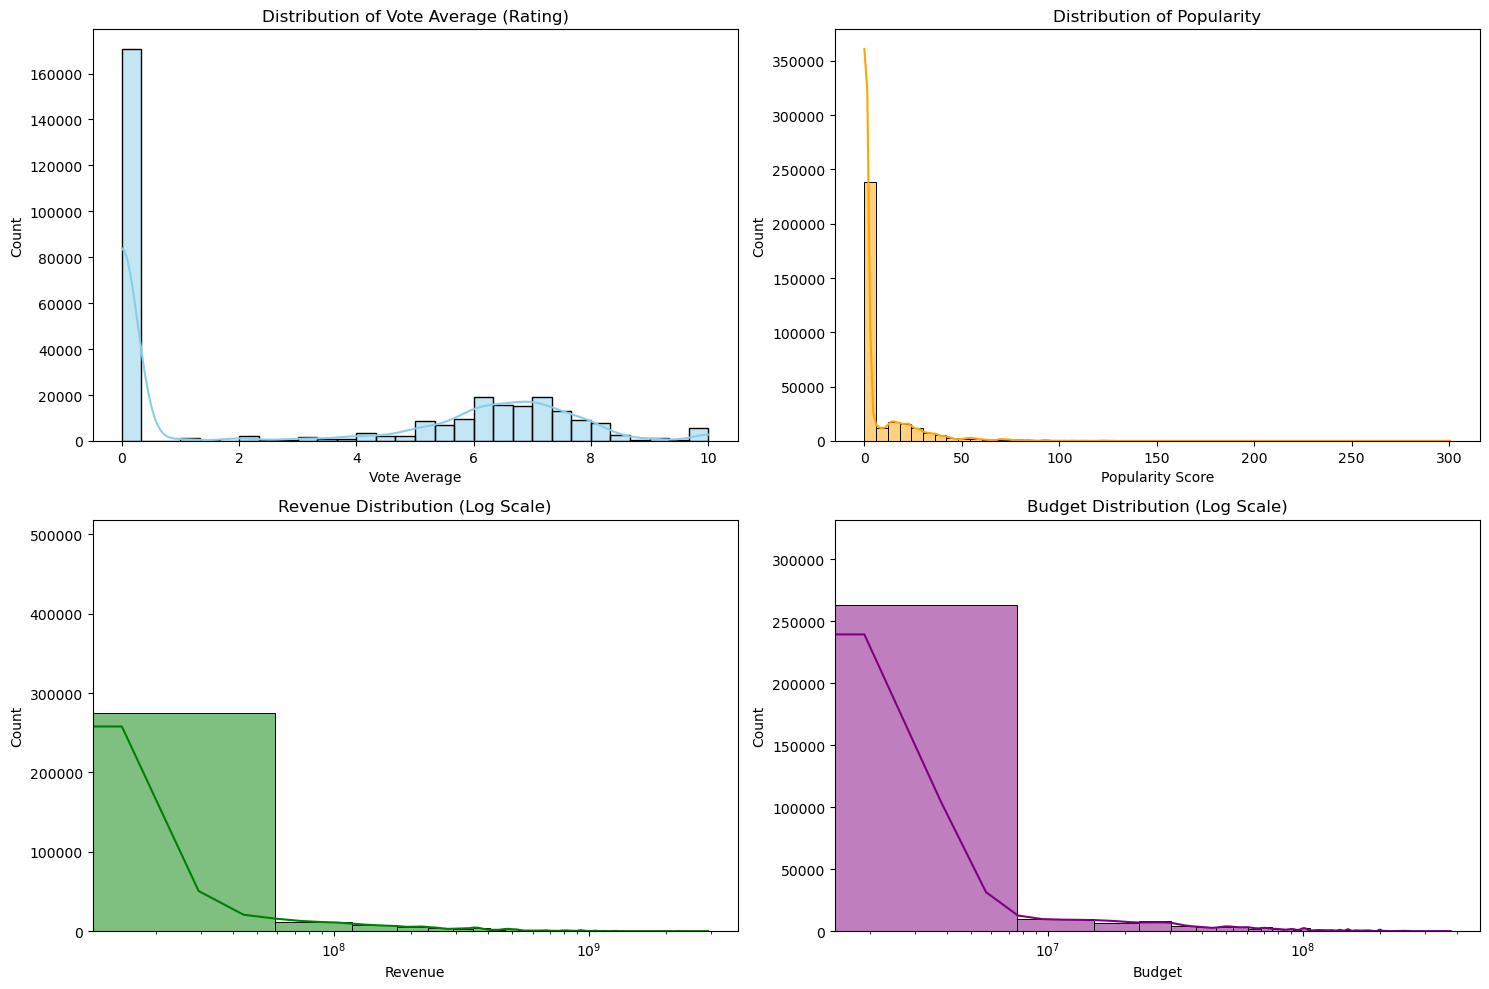

In [16]:
#  Distribution of Key Numerical Features ======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Vote Average Distribution
sns.histplot(final_dataset['vote_average'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Vote Average (Rating)')
axes[0,0].set_xlabel('Vote Average')

# Popularity Distribution
sns.histplot(final_dataset['popularity'], bins=50, kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribution of Popularity')
axes[0,1].set_xlabel('Popularity Score')

# Revenue Distribution (log scale because it's highly skewed)
sns.histplot(final_dataset['revenue'], bins=50, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Revenue Distribution (Log Scale)')
axes[1,0].set_xscale('log')
axes[1,0].set_xlabel('Revenue')

# Budget Distribution
sns.histplot(final_dataset['budget'], bins=50, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Budget Distribution (Log Scale)')
axes[1,1].set_xscale('log')
axes[1,1].set_xlabel('Budget')

plt.tight_layout()
plt.show()






# Movies Over Time
Insight:
* Movie production increases significantly in recent years
* Indicates dataset bias toward modern films

/home/ops/downloads/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


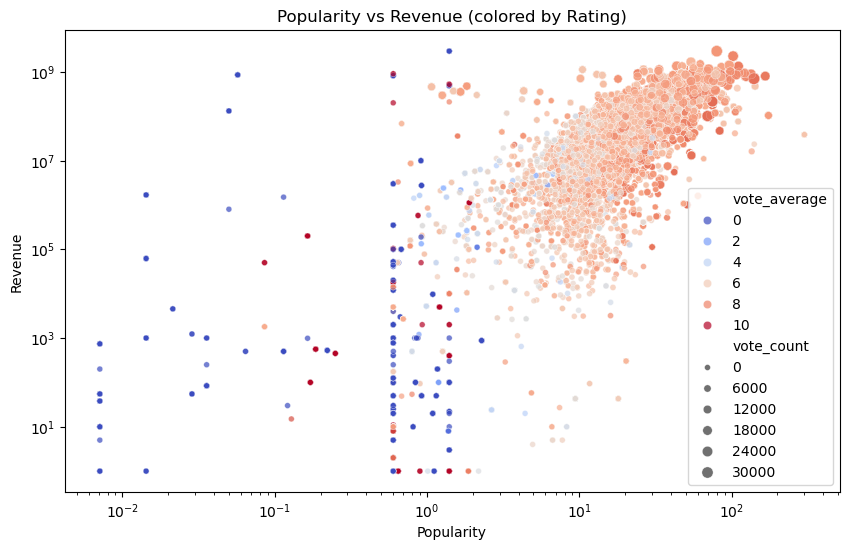

In [17]:
#  Scatter Plot: Popularity vs Revenue ======================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_dataset, x='popularity', y='revenue', hue='vote_average',
                size='vote_count', alpha=0.7, palette='coolwarm')
plt.title('Popularity vs Revenue (colored by Rating)')
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.xscale('log')
plt.yscale('log')
plt.show()



# Boxplot (Popularity Binned vs Rating)
Shows how ratings vary across popularity groups

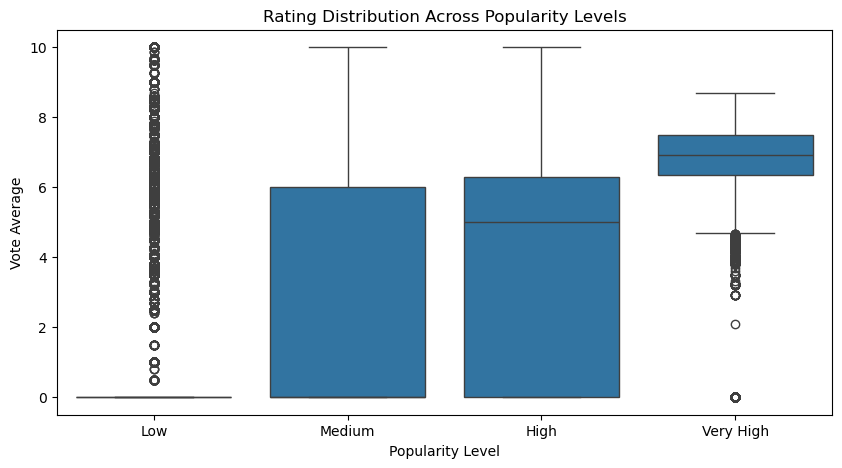

In [18]:
# Create bins for popularity
final_dataset['popularity_bin'] = pd.qcut(final_dataset['popularity'], 4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='popularity_bin',
    y='vote_average',
    data=final_dataset
)

plt.title("Rating Distribution Across Popularity Levels")
plt.xlabel("Popularity Level")
plt.ylabel("Vote Average")

plt.show()

## Correlation heatmap
*  It measures the strength of the linear relationship between your numerical variables, ranging from -1 to +1.

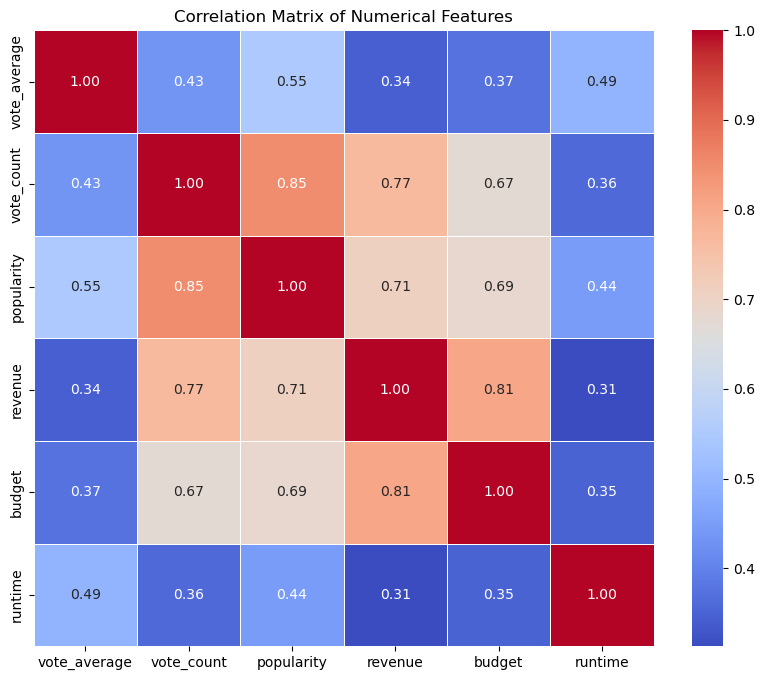

In [20]:
#  Correlation Heatmap ======================
numerical_cols = ['vote_average', 'vote_count', 'popularity', 'revenue', 'budget', 'runtime']

plt.figure(figsize=(10, 8))
corr_matrix = final_dataset[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

 # 7. Key Findings

### 7.1 Content Trends

* Drama and Action dominate movie production

### 7.2 Rating Insights

* High-rated movies are not always popular

### 7.3 Language Insights

* English movies dominate dataset

### 7.4 Dataset Bias

* More recent movies are overrepresented

---

# 8. Feature Engineering for Recommendation System

The dataset was prepared for recommendation modeling using:

* `combined_features` (text-based representation)
* Genre encoding
* Language encoding

This enables:

* Content-based filtering
* TF-IDF vectorization
* Cosine similarity modeling

---

# 9. Conclusion

This EDA provides a strong understanding of the dataset and prepares it for building a movie recommendation system. Key patterns in genres, ratings, and languages were identified, which will guide model development in later phases.

---

# 10. Next Steps

* Build TF-IDF vectorizer
* Compute cosine similarity
* Create recommendation function
* Evaluate recommendation quality

---

✔ End of EDA Report
